# K means Clustering
- Dataset: 
    1. Mall Customers Dataset: https://www.kaggle.com/datasets/shwetabh123/mall-customers
- References:
    1. https://www.geeksforgeeks.org/machine-learning/k-means-clustering-introduction/
    2. https://youtu.be/5FpsGnkbEpM?si=INRMJRRR7ZQJ8Jtk

- Unsupervised Learning
- Groups similar data into clusters
- Assign points to the nearest centroid

# Product Component Analysis (PCA)
- used in unsupervised learning to reduce dimensionality
- Step 1: Calculate Mean of every feature
- Step 2: Calculate the Covariance Matrix
- Step 3: Calculate eigenvalues and eigenvectors
- Step 4: Choose Principal Components
- Step 5: Project Data onto Principal Components
- Reference: https://youtu.be/Dv-Kk7PDEas?si=GCLeuFGBGxE84_nN

- PCA before K mean Clustering
    - Improving the Clusters
- PCA after K mean Clustering
    - Visualization

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def distance(p1, p2):
    return np.sqrt(np.sum((p1 - p2)**2))

def assign_clusters(X, clusters):
    k = len(clusters)
    for idx in range(X.shape[0]):
        dist = []
        curr_x = X[idx]
        for i in range(k):
            dis = distance(curr_x, clusters[i]['center'])
            dist.append(dis)
        curr_cluster = np.argmin(dist)
        clusters[curr_cluster]['points'].append(curr_x)
    return clusters

def update_clusters(clusters):
    k = len(clusters)
    for i in range(k):
        points = np.array(clusters[i]['points'])
        if points.shape[0] > 0:
            new_center = points.mean(axis=0)
            clusters[i]['center'] = new_center
            
        #Reset points for the next iteration
        clusters[i]['points'] = []
    return clusters

def pred_cluster(X, clusters):
    k = len(clusters)
    pred = []
    for i in range(X.shape[0]):
        dist = []
        for j in range(k):
            dist.append(distance(X[i], clusters[j]['center']))
        pred.append(np.argmin(dist))
    return pred

def kmeansclustering_runner(file_path, k=3, max_iter=10, cols_to_drop=None):
    #load dataset
    df = pd.read_csv(file_path)
    
    #drop unnecessary columns (like IDs, Names, etc.)
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop, errors='ignore')
        
    #features (X)
    X = df
    y = None

    X = pd.get_dummies(X, drop_first=True, dtype=float)
     
    #feature scaling using StandardScaler
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score

    inertias = []
    sil_scores = []
    k_range = range(2, 15)

    for k_test in k_range:
        km = KMeans(n_clusters=k_test, init='k-means++', n_init=10, random_state=23)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        sil_scores.append(silhouette_score(X, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker='o')
    axes[0].set_title("Elbow Method")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("Inertia")

    axes[1].plot(list(k_range), sil_scores, marker='o', color='green')
    axes[1].set_title("Silhouette Score")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Score")
    plt.show()

    #Initializing Random Centroids
    clusters = {}
    np.random.seed(23)

    for idx in range(k):
        np.random.seed(23)
        indices = np.random.choice(X.shape[0], k, replace=False)
        for idx in range(k):
            clusters[idx] = {
                'center': X[indices[idx]],
                'points': []
            }
        
    #Plotting Random Initialized Centers with Data Points
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:,0], X[:,1], c='lightgray', label='Data points')
    for i in clusters:
        center = clusters[i]['center']
        plt.scatter(center[0], center[1], marker='*', s=150, c='red')
    plt.title("Initial Random Centroids")
    plt.grid(True)
    plt.show()
    
    #Iteratively assigning, Updating and Predicting the Cluster Centers
    for _ in range(max_iter):
        clusters = assign_clusters(X, clusters)
        clusters = update_clusters(clusters)
        
    pred = pred_cluster(X, clusters)

    #Plotting Data Points with Predicted Cluster Centers
    plt.figure(figsize=(8, 5))
    plt.scatter(X[:,0], X[:,1], c=pred, cmap='viridis')
    for i in clusters:
        center = clusters[i]['center']
        plt.scatter(center[0], center[1], marker='^', s=150, c='red', edgecolors='black')
    plt.title("Final K-Means Clusters")
    plt.grid(True)
    plt.show()
    
    # Compress the scaled dataset into exactly 2 dimensions for graphing
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    #Extract our final cluster centers (which are currently 4D/5D) and push them through the exact same PCA transformation
    centers = np.array([clusters[i]['center'] for i in range(k)])
    centers_pca = pca.transform(centers)

    # Plot the PCA-reduced data points
    plt.figure(figsize=(10, 6))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=pred, cmap='viridis', alpha=0.7)
    
    # Plot the PCA-reduced cluster centers
    for i in range(k):
        plt.scatter(centers_pca[i, 0], centers_pca[i, 1], marker='^', s=200, c='red', edgecolors='black')
        
    plt.title(f"Final K-Means Clusters Visualized with PCA (k={k})")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True)
    plt.show()

    #Returning the final predictions and cluster coordinates makes this function reusable
    return pred, clusters, X

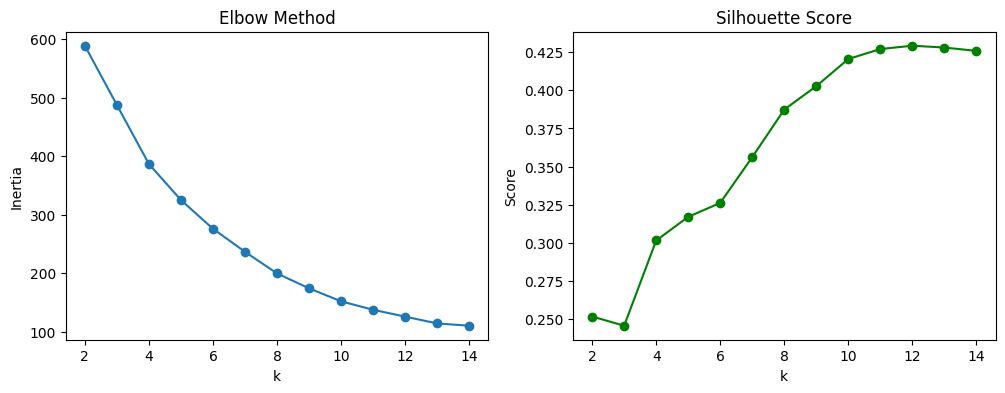

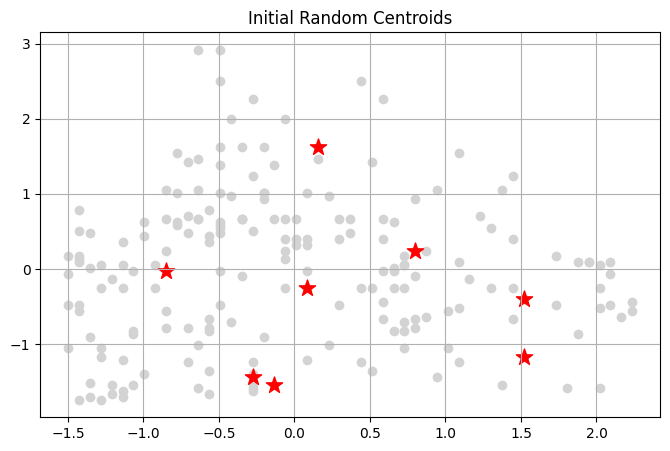

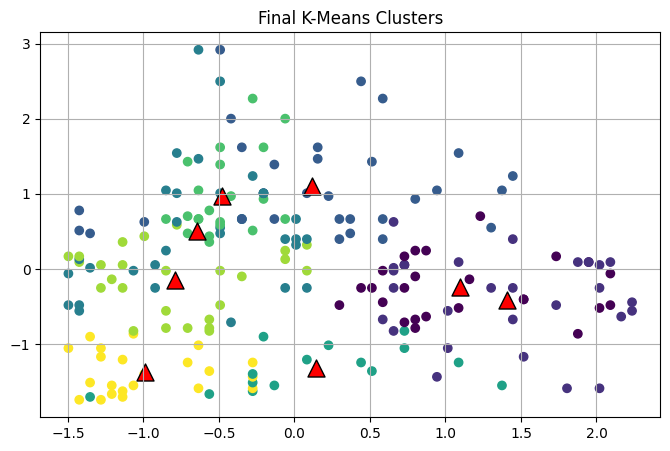

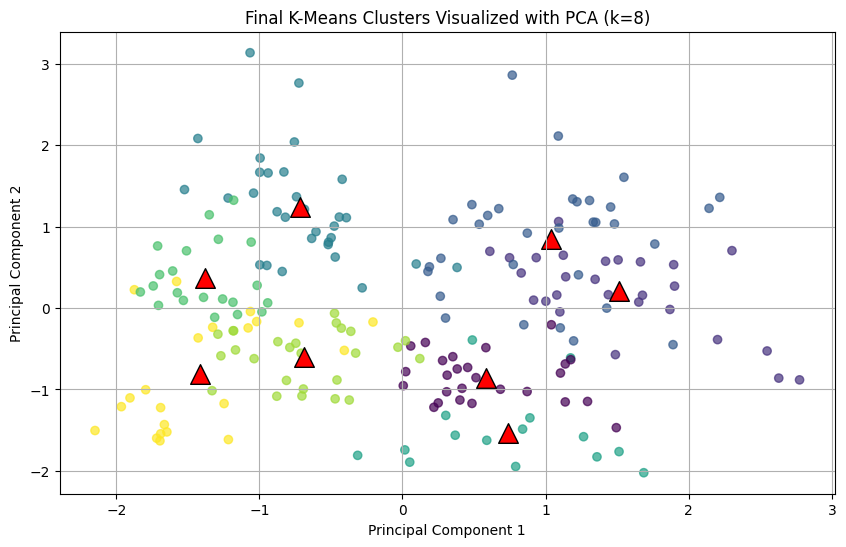

          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        54.2                54.2                    49.0
1        58.4                49.7                    39.7
2        40.5                89.4                    16.3
3        29.9                73.8                    70.2
4        40.8                25.9                    21.1
5        32.2                86.0                    81.7
6        27.8                56.7                    47.8
7        25.0                24.6                    78.2
Cluster
0    26
1    27
2    32
3    31
4    15
5    21
6    26
7    22
Name: count, dtype: int64


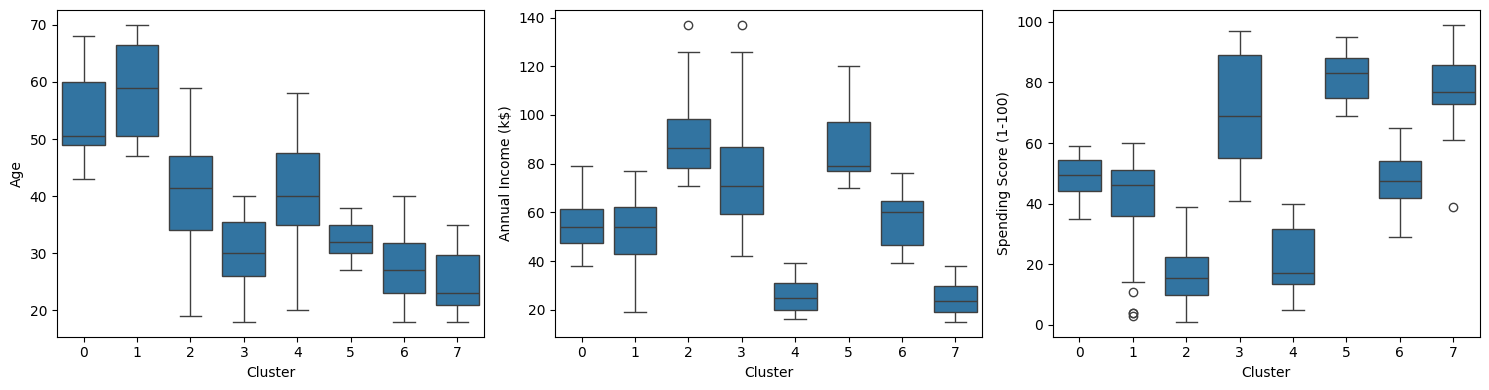

In [54]:
mall_preds, mall_clusters, mall_x = kmeansclustering_runner(
    file_path= 'Mall_Customers.csv',
    k=8, 
    max_iter=10, 
    cols_to_drop=['CustomerID'])

#Profiling
#load the original (unscaled) dataset again so values are human-readable
df = pd.read_csv('Mall_Customers.csv')
df = df.drop(columns=['CustomerID'], errors='ignore')

df['Cluster'] = mall_preds  

# 1. Average feature values per cluster — the main profiling table
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(profile)

# 2. Cluster sizes — how many customers fall in each group
print(df['Cluster'].value_counts().sort_index())

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']):
    sns.boxplot(x='Cluster', y=col, data=df, ax=ax)
plt.tight_layout()
plt.show()

In [55]:
#classification using decision tree + random forest
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(mall_x, mall_preds, test_size=0.2, random_state=23, stratify=mall_preds)

#Decision Tree with GridSearchCV
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=23), dt_params, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

print("Best Decision Tree params:", dt_grid.best_params_)
print("Best CV accuracy:", dt_grid.best_score_.round(3))

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test)
print("Test accuracy:", round(accuracy_score(y_test, y_pred_dt), 3))
print(classification_report(y_test, y_pred_dt))

Best Decision Tree params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 5}
Best CV accuracy: 0.95
Test accuracy: 0.925
              precision    recall  f1-score   support

           0       0.80      0.80      0.80         5
           1       1.00      0.83      0.91         6
           2       0.78      1.00      0.88         7
           3       1.00      1.00      1.00         6
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         4

    accuracy                           0.93        40
   macro avg       0.95      0.91      0.92        40
weighted avg       0.94      0.93      0.92        40



## Selecting value of k
- to improve the clusters
- elbow method: k = 8
- silhouette score: k = 10-12

- k=12 it just keeps creating extra clusters on the right side
- k = 10
    - best CV accuracy = 0.912
    - Test accuracy: 0.95
- k = 8
    - best CV accuracy = 0.95
    - test accuracy = 0.925
- k = 5
    - best CV accuracy = 0.862
    - test accuracy = 0.975

- I chose k=8 because three things pointed to it: the silhouette score leveled off around k=8, it had the highest cross-validation accuracy (0.95) of all the k values I tested, and its clusters had more balanced, reliable sample sizes than k=5 or k=10, which were prone to inflated or unstable scores from very small clusters.

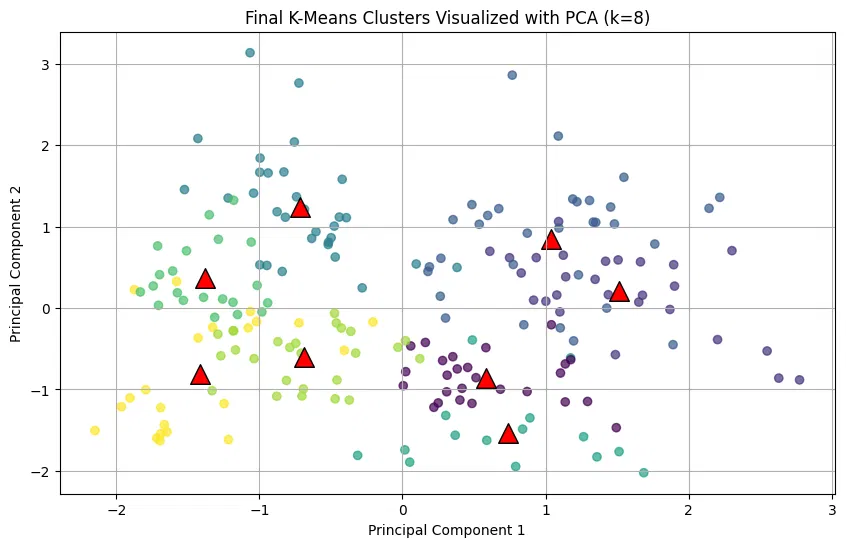

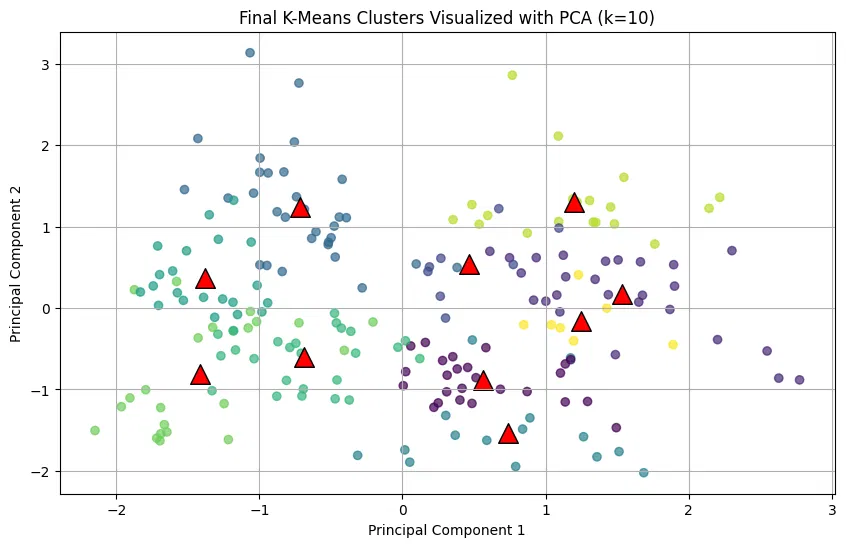

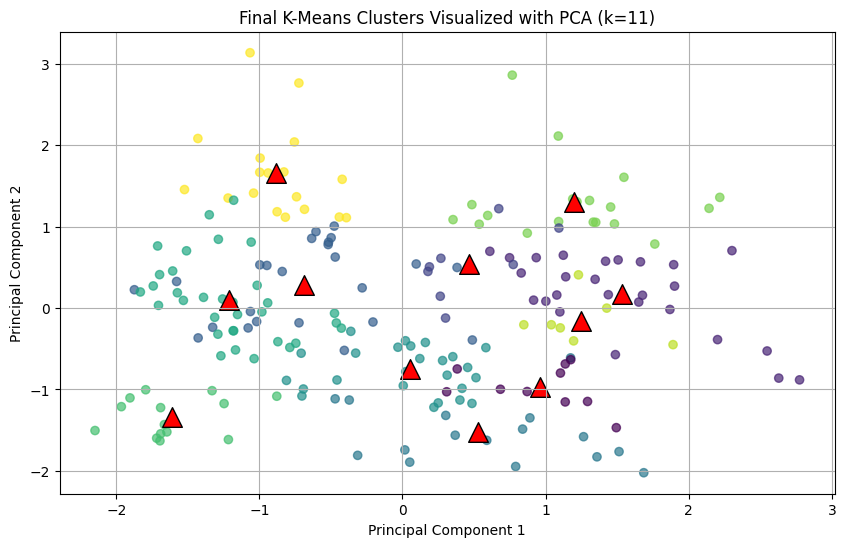